# Seasonal-Naive Baseline (Lag 48)

This notebook generates the seasonal-naive test forecasts required for the F1 degradation curve, for **SA1** and **NSW1** separately. For half-hourly AEMO demand data, 48 intervals equal one day, so the forecast is $\hat{y}_t = y_{t-48}$.

The model is frozen: the lag-48 rule never changes. Actual observations that have already arrived may be used as lagged inputs; this is forecasting, not retraining.

## Key concepts

**Degradation curve (F1)** — A frozen model is trained (or defined) once and never updated, even as new data arrives. "Degradation" is what happens when the real-world process drifts away from what that frozen model assumes, so its forecast error grows over time. The F1 curve is a plot of a rolling error metric against time for each frozen baseline; a rising line means the model is degrading (a sign of concept drift), a flat line means it's still keeping pace. This notebook produces the seasonal-naive line of that curve — later notebooks will overlay the classical and gradient-boosted model lines on the same axis.

**Seasonal-naive & lag** — Seasonal-naive is the simplest possible frozen baseline: it never learns anything and is never retrained. Its forecast at time $t$ is just the observed value one season ago, $\hat{y}_t = y_{t-L}$, where $L$ is the "lag." AEMO demand is recorded every 30 minutes, and one full day = 48 such intervals, so $L=48$ ("lag 48") means the forecast for any half-hour is literally "same time yesterday."

**MAE** — Mean Absolute Error, $\frac{1}{n}\sum_i |y_i - \hat{y}_i|$, measured in MW (same units as demand). It's the average size of the forecast miss — e.g. an MAE of 150 MW means forecasts are typically off by about 150 MW, too high or too low.

**Rolling MAE (7-day)** — Rather than a single MAE number for the whole test period, MAE is recomputed on a sliding 7-day window (336 half-hourly forecasts) ending at every timestamp. This turns one summary statistic into a time series, which is what makes degradation visible: a rising or widening rolling-MAE line means the frozen lag-48 rule is missing by more, more often, as time goes on. A 7-day window is used (rather than 1 day) to smooth out normal weekday/weekend noise while staying short enough to localize *when* things got worse.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from drift_forecasting.config import (
    DATA_DIR,
    PROCESSED_DATA_DIR,
    REGIONS,
    ROLLING_WINDOW_DAYS,
    SEASON_LENGTH,
)


## 1. Load the frozen splits for each region

The train / calibration / test split is frozen by `config.SPLIT` and was already applied by [`splits.py`](../../src/drift_forecasting/data/splits.py), which wrote `{REGION}_train.csv`, `{REGION}_calibration.csv`, and `{REGION}_test.csv` to `data/processed/`. This notebook only reads those files, for both regions in `config.REGIONS`.

In [2]:
TIMESTAMP_COLUMN = "SETTLEMENTDATE"
TARGET_COLUMN = "TOTALDEMAND"
SEASONAL_LAG = SEASON_LENGTH  # 48 half-hourly intervals = 1 day
ROLLING_WINDOW = ROLLING_WINDOW_DAYS * SEASON_LENGTH  # 336 half-hourly forecasts

# Every artefact this notebook produces (forecast CSVs + F1 figures) goes here,
# so nothing lands in the working directory. DATA_DIR is absolute, so this
# resolves the same whether the notebook is run from the repo root or from
# notebooks/exploration/.
OUTPUT_DIR = DATA_DIR / "baseline" / "seasonal_naive"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Writing outputs to {OUTPUT_DIR}")


def load_split(region: str, split_name: str) -> pd.DataFrame:
    path = PROCESSED_DATA_DIR / f"{region}_{split_name}.csv"
    df = pd.read_csv(path)
    df[TIMESTAMP_COLUMN] = pd.to_datetime(df[TIMESTAMP_COLUMN])
    return df.sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)


splits = {}

for region in REGIONS:
    splits[region] = {
        "train": load_split(region, "train"),
        "calibration": load_split(region, "calibration"),
        "test": load_split(region, "test"),
    }

    print(f"{region}")
    for split_name, split_df in splits[region].items():
        print(
            f"  {split_name}: {split_df[TIMESTAMP_COLUMN].min()} "
            f"to {split_df[TIMESTAMP_COLUMN].max()} "
            f"({len(split_df):,} rows)"
        )


Writing outputs to /Users/phong/University/Capstone/Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting/data/baseline/seasonal_naive
SA1
  train: 2018-01-01 00:30:00 to 2019-12-31 23:30:00 (35,039 rows)
  calibration: 2020-01-01 00:00:00 to 2020-02-29 23:30:00 (2,880 rows)
  test: 2020-03-01 00:00:00 to 2024-01-01 00:00:00 (67,249 rows)
NSW1
  train: 2018-01-01 00:30:00 to 2019-12-31 23:30:00 (35,039 rows)
  calibration: 2020-01-01 00:00:00 to 2020-02-29 23:30:00 (2,880 rows)
  test: 2020-03-01 00:00:00 to 2024-01-01 00:00:00 (67,249 rows)


## 2. Generate frozen seasonal-naive forecasts

For each region, the splits are concatenated only so that the lag-48 rule can reach back across the test boundary — the first test day is predicted from already-known calibration observations. This does not fit or update a model: the prediction for each timestamp is simply the observed demand 48 rows earlier.

The test period is then sliced out, and absolute error and the 7-day rolling MAE are computed **strictly on the test slice**. Because the rolling window needs a full 336 in-test errors before it reports a value (`min_periods=ROLLING_WINDOW`), the first 335 test intervals — roughly the first week of the test stream — have no rolling MAE and appear as a gap at the left edge of the 2020 panel. This keeps the F1 line a pure function of test-period behaviour, with no pre-test errors bleeding into the window.

In [3]:
def seasonal_naive_forecast(
    region_splits: dict[str, pd.DataFrame],
) -> pd.DataFrame:
    history = (
        pd.concat(
            [
                region_splits["train"],
                region_splits["calibration"],
                region_splits["test"],
            ],
            ignore_index=True,
        )
        .sort_values(TIMESTAMP_COLUMN)
        .reset_index(drop=True)
    )

    # Generate lag-48 predictions across the continuous timeline so the first
    # test rows can be predicted from calibration observations.
    history["PREDICTION"] = (
        history[TARGET_COLUMN].shift(SEASONAL_LAG)
    )

    test_start = region_splits["test"][TIMESTAMP_COLUMN].min()
    test_end = region_splits["test"][TIMESTAMP_COLUMN].max()

    # Slice the test period before calculating any errors or rolling MAE.
    results = history.loc[
        history[TIMESTAMP_COLUMN].between(test_start, test_end),
        [
            TIMESTAMP_COLUMN,
            TARGET_COLUMN,
            "PREDICTION",
        ],
    ].copy()

    # Confirm that every test observation has a prediction.
    missing_predictions = results["PREDICTION"].isna().sum()

    if missing_predictions:
        raise ValueError(
            f"Test set contains "
            f"{missing_predictions} missing predictions"
        )

    # Absolute error on the test slice only.
    results["ABSOLUTE_ERROR"] = (
        results[TARGET_COLUMN] - results["PREDICTION"]
    ).abs()

    # Rolling MAE strictly over test-period errors: the window must be full
    # (min_periods == window), so the first 335 test rows stay NaN.
    results["ROLLING_MAE_7D"] = (
        results["ABSOLUTE_ERROR"]
        .rolling(
            window=ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        )
        .mean()
    )

    return results


seasonal_results = {
    region: seasonal_naive_forecast(region_splits)
    for region, region_splits in splits.items()
}

for region, results in seasonal_results.items():
    print(region)
    display(results.head())


SA1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
37919,2020-03-01 00:00:00,1377.68,1412.56,34.88,NaN
37920,2020-03-01 00:30:00,1330.34,1365.10,34.76,NaN
37921,2020-03-01 01:00:00,1261.70,1305.29,43.59,NaN
37922,2020-03-01 01:30:00,1182.48,1230.98,48.50,NaN
37923,2020-03-01 02:00:00,1129.30,1193.63,64.33,NaN


NSW1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
37919,2020-03-01 00:00:00,7019.06,7146.84,127.78,NaN
37920,2020-03-01 00:30:00,6843.16,6991.19,148.03,NaN
37921,2020-03-01 01:00:00,6674.67,6783.37,108.70,NaN
37922,2020-03-01 01:30:00,6417.07,6503.91,86.84,NaN
37923,2020-03-01 02:00:00,6221.79,6347.40,125.61,NaN


## 3. Inspect the forecasts and errors

In [4]:
for region, results in seasonal_results.items():
    print(f"{region}")
    print(f"  Test forecasts: {len(results):,}")
    print(f"  Overall test MAE: {results['ABSOLUTE_ERROR'].mean():,.2f} MW")
    print(f"  Missing forecasts: {results['PREDICTION'].isna().sum()}")

# The leading rolling-MAE gap is checked in the validation cell below.

for region, results in seasonal_results.items():
    print(region)
    display(results[[
        TIMESTAMP_COLUMN, TARGET_COLUMN, "PREDICTION",
        "ABSOLUTE_ERROR", "ROLLING_MAE_7D"
    ]].tail())


SA1
  Test forecasts: 67,249
  Overall test MAE: 155.87 MW
  Missing forecasts: 0
NSW1
  Test forecasts: 67,249
  Overall test MAE: 442.27 MW
  Missing forecasts: 0
SA1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
105163,2023-12-31 22:00:00,1285.116667,1278.400000,6.716667,164.602267
105164,2023-12-31 22:30:00,1278.321667,1256.588333,21.733333,164.506042
105165,2023-12-31 23:00:00,1249.976667,1224.385000,25.591667,164.477302
105166,2023-12-31 23:30:00,1237.001667,1216.035000,20.966667,164.444271
105167,2024-01-01 00:00:00,1306.250000,1293.030000,13.220000,164.363765


NSW1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
105163,2023-12-31 22:00:00,6968.330000,7249.076667,280.746667,562.895585
105164,2023-12-31 22:30:00,6857.930000,7083.116667,225.186667,562.545124
105165,2023-12-31 23:00:00,6782.018333,6915.866667,133.848333,561.936989
105166,2023-12-31 23:30:00,6663.935000,6700.796667,36.861667,560.769707
105167,2024-01-01 00:00:00,6633.123333,6610.108333,23.015000,559.527366


In [5]:
# Validate the rolling-MAE gap: every NaN must be one of the first
# (ROLLING_WINDOW - 1) test rows, and nothing after that may be NaN.
WARMUP_ROWS = ROLLING_WINDOW - 1  # 335

for region, results in seasonal_results.items():
    rolling_mae = results["ROLLING_MAE_7D"].reset_index(drop=True)
    nan_positions = rolling_mae.index[rolling_mae.isna()]

    total_nan = len(nan_positions)
    leading_only = list(nan_positions) == list(range(total_nan))
    gap_is_warmup = total_nan == WARMUP_ROWS
    rest_all_filled = rolling_mae.iloc[WARMUP_ROWS:].notna().all()

    print(f"{region}")
    print(f"  Total NaN in ROLLING_MAE_7D: {total_nan}")
    print(f"  NaNs are exactly the first {total_nan} rows (contiguous, no gaps later): {leading_only}")
    print(f"  Gap length == ROLLING_WINDOW - 1 ({WARMUP_ROWS}): {gap_is_warmup}")
    print(f"  All rows from index {WARMUP_ROWS} onward are filled: {rest_all_filled}")
    print(f"  First filled timestamp: {results[TIMESTAMP_COLUMN].iloc[WARMUP_ROWS]}")

    assert leading_only and gap_is_warmup and rest_all_filled, (
        f"{region}: rolling-MAE NaNs are not exactly the first {WARMUP_ROWS} test rows"
    )


SA1
  Total NaN in ROLLING_MAE_7D: 335
  NaNs are exactly the first 335 rows (contiguous, no gaps later): True
  Gap length == ROLLING_WINDOW - 1 (335): True
  All rows from index 335 onward are filled: True
  First filled timestamp: 2020-03-07 23:30:00
NSW1
  Total NaN in ROLLING_MAE_7D: 335
  NaNs are exactly the first 335 rows (contiguous, no gaps later): True
  Gap length == ROLLING_WINDOW - 1 (335): True
  All rows from index 335 onward are filled: True
  First filled timestamp: 2020-03-07 23:30:00


In [6]:
# Persist the per-region forecast + rolling-MAE table so later F1 notebooks
# (classical, gradient-boosted) can overlay their lines without re-running this.
for region, results in seasonal_results.items():
    out_path = OUTPUT_DIR / f"{region}_seasonal_naive_test.csv"
    results.to_csv(out_path, index=False)
    print(f"{region}: wrote {len(results):,} rows")


SA1: wrote 67,249 rows


NSW1: wrote 67,249 rows


## 4. Plot the seasonal-naive F1 line

A single figure covers the whole test period, with SA1 and NSW1 on the same axes. The final F1 figure (in the comparison notebook) overlays the classical and gradient-boosted rolling-MAE lines on these same axes; per-region breakdowns with `events.csv` annotations follow in section 4a.

Figures are written to `data/baseline/seasonal_naive/`: `f1_rolling_mae_full.png` for the combined figure, `f1_rolling_mae_{region}_{year}.png` for the per-region panels — alongside the `{region}_seasonal_naive_test.csv` tables from section 3.

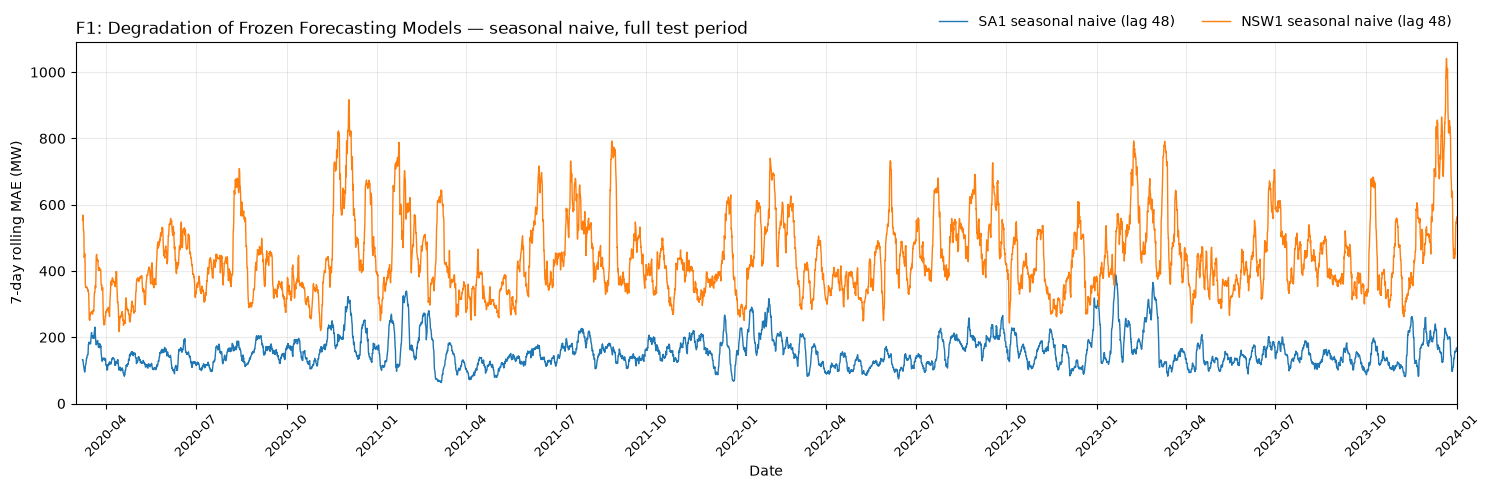

In [7]:
def format_month_axis(ax: plt.Axes, year: int) -> None:
    ax.set_xlim(pd.Timestamp(year=year, month=1, day=1), pd.Timestamp(year=year + 1, month=1, day=1))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.grid(alpha=0.25)
    ax.grid(which="major", axis="x", alpha=0.4, linewidth=0.5)


# Calendar years present anywhere in the test period, across both regions.
# AEMO timestamps an interval by its *end*, so the very last row of the
# test period is stamped 2024-01-01 00:00:00 even though it covers the
# last half-hour of 2023-12-31 — a single point, not a real 2024 year of
# data, so years with fewer than 2 rows are dropped. Used by the per-region
# panels in section 4a.
test_years = [
    year
    for year in sorted({
        timestamp.year
        for results in seasonal_results.values()
        for timestamp in results[TIMESTAMP_COLUMN]
    })
    if all(
        (results[TIMESTAMP_COLUMN].dt.year == year).sum() >= 2
        for results in seasonal_results.values()
    )
]

# One figure for the whole test period, both regions on the same axes.
PERIOD_START = pd.Timestamp("2020-03-01")
PERIOD_END = pd.Timestamp("2024-01-01")

fig, ax = plt.subplots(figsize=(15, 5))

for region, results in seasonal_results.items():
    ax.plot(
        results[TIMESTAMP_COLUMN],
        results["ROLLING_MAE_7D"],
        label=f"{region} seasonal naive (lag 48)",
        linewidth=1.0,
    )

ax.set_title(
    "F1: Degradation of Frozen Forecasting Models — seasonal naive, full test period",
    loc="left",
)
ax.set_xlabel("Date")
ax.set_ylabel("7-day rolling MAE (MW)")
ax.set_xlim(PERIOD_START, PERIOD_END)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))  # quarterly ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", labelrotation=45, labelsize=9)
ax.grid(alpha=0.25)
ax.grid(which="major", axis="x", alpha=0.4, linewidth=0.5)
ax.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.02),
    ncol=len(seasonal_results),
    frameon=False,
    borderaxespad=0.0,
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "f1_rolling_mae_full.png", dpi=130, bbox_inches="tight")
plt.show()


**What the figure shows:** error is cyclical, not a single one-off break — both lines repeatedly rise and fall, tracking the Australian seasons: rolling MAE peaks every summer (roughly Nov–Feb, across the turn of the calendar year) and troughs every autumn (roughly Mar–May). NSW1 sits well above SA1 throughout, consistent with NSW1's much larger absolute demand.

The first clear degradation episode for both regions is **Nov 2020 – Feb 2021**: after a comparatively calm Mar–Oct 2020 (the line begins 7 Mar, once the 7-day rolling window has filled on test-period errors), rolling MAE roughly doubles for NSW1 (peaking near 917 MW in Dec 2020) and rises ~80 % for SA1 (peaking near 339 MW in Jan 2021). The same summer pattern then recurs every year, so this reads as a recurring seasonal effect rather than a permanent regime change — except at the very end of the series (**Nov–Dec 2023**), where the degradation is the largest on record and does not fully subside before the test data run out; see the per-region plots below for detail.

*Note:* the test data's last row is stamped `2024-01-01 00:00:00`, which is just AEMO's end-of-interval label for the final half-hour of 2023-12-31 — not a real 2024 observation. That single point is still counted in the "Overall test MAE" figures above and in the per-region commentary below.

### 4a. Per-region rolling-MAE plots

SA1 and NSW1 sit on very different demand scales, so the combined figure above compresses SA1's degradation pattern. One figure per region per year, each on its own y-axis, makes each region's pattern easier to read.

Documented events from `events.csv` are overlaid in red. A precise-date event is a single dashed vertical line with its label printed horizontally next to it; a period event is two dashed lines with a light shaded band between them and its label printed horizontally, centred inside that band. The label is the `event_name` column. NEM-wide events appear on both regions' panels; region-specific events appear only on that region's. Rows with an unparseable date are skipped with a warning.

In [8]:
# Documented AEMO/AER events, used to annotate the per-region panels below.
EVENTS_PATH = next(
    path
    for path in (Path("events.csv"), Path("notebooks/exploration/events.csv"))
    if path.exists()
)
events = pd.read_csv(EVENTS_PATH)
events["start_date"] = pd.to_datetime(events["start_date"], format="%Y-%m-%d", errors="coerce")
events["end_date"] = pd.to_datetime(events["end_date"], format="%Y-%m-%d", errors="coerce")

# Drop (and flag) any row whose dates did not parse, so a typo in events.csv
# cannot break every panel.
unparseable = events[events["start_date"].isna() | events["end_date"].isna()]
if not unparseable.empty:
    print("WARNING: skipping events with unparseable dates:")
    display(unparseable[["event_id", "event_name", "start_date", "end_date"]])
    events = events.dropna(subset=["start_date", "end_date"]).reset_index(drop=True)

print(f"Loaded {len(events)} events from {EVENTS_PATH}")
display(events[["event_id", "event_name", "start_date", "end_date", "region", "event_type"]])

# Annotation rules:
#   - region == "NEM"          -> drawn on both the SA1 and the NSW1 panels
#   - region == "SA1" / "NSW1"  -> drawn only on that region's panels
#   - start_date == end_date    -> one dashed vertical line (a point in time);
#                                  the label sits next to the line
#   - start_date != end_date    -> two dashed vertical lines + a light band;
#                                  the label sits centred within the band
#   - the label is the event_name column (already unique and human-readable);
#     the event_id is not shown
EVENT_COLOR = "tab:red"
EVENT_LINE_KW = dict(color=EVENT_COLOR, linestyle="--", linewidth=1.0, alpha=0.7)
EVENT_SPAN_KW = dict(color=EVENT_COLOR, alpha=0.07, linewidth=0)
_LABEL_LEVELS = (0.96, 0.87, 0.78, 0.69, 0.60, 0.51)
_LABEL_GAP = pd.Timedelta(days=2)


def annotate_events(ax: plt.Axes, region: str, year: int) -> None:
    year_start = pd.Timestamp(year=year, month=1, day=1)
    year_end = pd.Timestamp(year=year + 1, month=1, day=1)

    in_scope = events[
        events["region"].isin([region, "NEM"])
        & (events["start_date"] < year_end)
        & (events["end_date"] >= year_start)
    ].sort_values("start_date")

    for i, (_, event) in enumerate(in_scope.iterrows()):
        is_period = event["end_date"] != event["start_date"]
        level = _LABEL_LEVELS[i % len(_LABEL_LEVELS)]
        label = event["event_name"]

        if is_period:
            for edge in (event["start_date"], event["end_date"]):
                if year_start <= edge < year_end:
                    ax.axvline(edge, **EVENT_LINE_KW)

            span_start = max(event["start_date"], year_start)
            span_end = min(event["end_date"], year_end)
            ax.axvspan(span_start, span_end, **EVENT_SPAN_KW)

            # Label kept horizontal and centred between the two period markers.
            ax.text(
                span_start + (span_end - span_start) / 2,
                level,
                label,
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=6.5,
                color=EVENT_COLOR,
            )
        else:
            edge = event["start_date"]
            ax.axvline(edge, **EVENT_LINE_KW)

            # Label kept horizontal, next to the line; flip to the left near the
            # right edge so the text stays on the axes.
            near_right = edge > year_end - pd.Timedelta(days=45)
            ax.text(
                edge - _LABEL_GAP if near_right else edge + _LABEL_GAP,
                level,
                label,
                transform=ax.get_xaxis_transform(),
                ha="right" if near_right else "left",
                va="top",
                fontsize=6.5,
                color=EVENT_COLOR,
            )


Loaded 28 events from events.csv


,event_id,event_name,start_date,end_date,region,event_type
0,EVT-2020-01,NSW bushfire-related high demand - 4 Jan 2020,2020-01-04,2020-01-04,NSW1,high_demand
1,EVT-2020-02,NEM COVID-19 demand change - 1 Apr-17 May 2020,2020-04-01,2020-04-16,NEM,covid_demand_change
2,EVT-2020-04,NEM winter minimum demand record - 29 Aug 2020,2020-08-29,2020-08-29,NEM,minimum_demand
3,EVT-2020-06,SA solar-supplied minimum demand - 11 Oct 2020,2020-10-11,2020-10-11,SA1,minimum_demand
4,EVT-2020-07,NEM December solar and mild-weather demand ero...,2020-12-01,2020-12-31,NEM,gradual_solar_demand_shift
5,EVT-2021-01,SA minimum-demand intervention - 14 Mar 2021,2021-03-14,2021-03-14,SA1,minimum_demand_intervention
6,EVT-2021-08,NSW cold-weather high demand - 10 Jun 2021,2021-06-10,2021-06-10,NSW1,high_demand
7,EVT-2021-02,NSW lockdown demand reduction - Aug 2021,2021-08-01,2021-08-31,NSW1,covid_demand_change
8,EVT-2021-03,NSW minimum demand record - 19 Sep 2021,2021-09-19,2021-09-19,NSW1,minimum_demand
9,EVT-2021-04,SA minimum demand record - 26 Sep 2021,2021-09-26,2021-09-26,SA1,minimum_demand


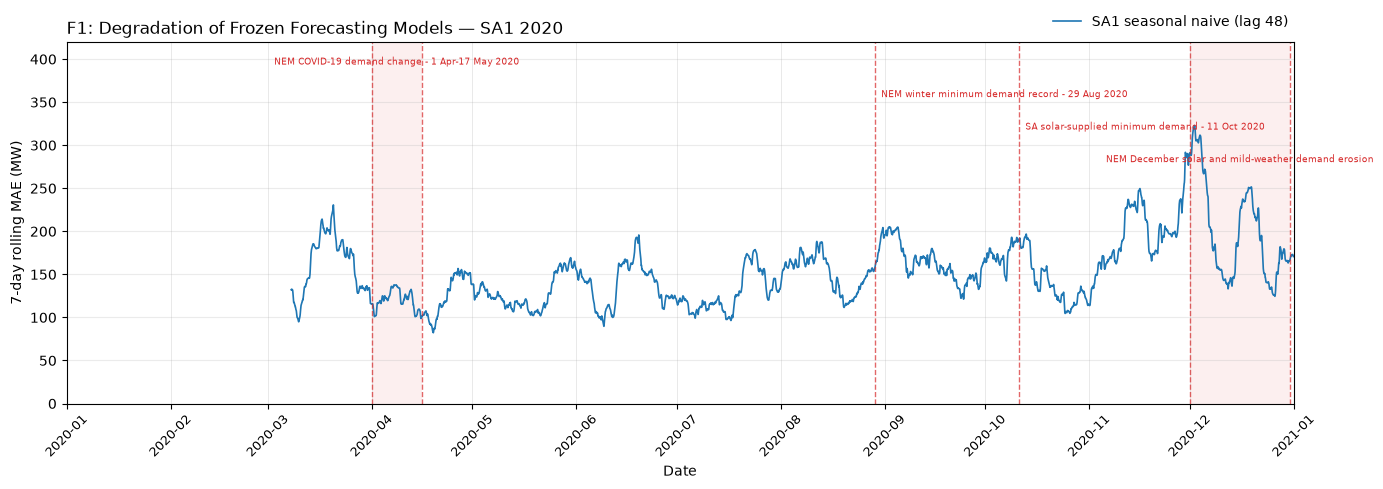

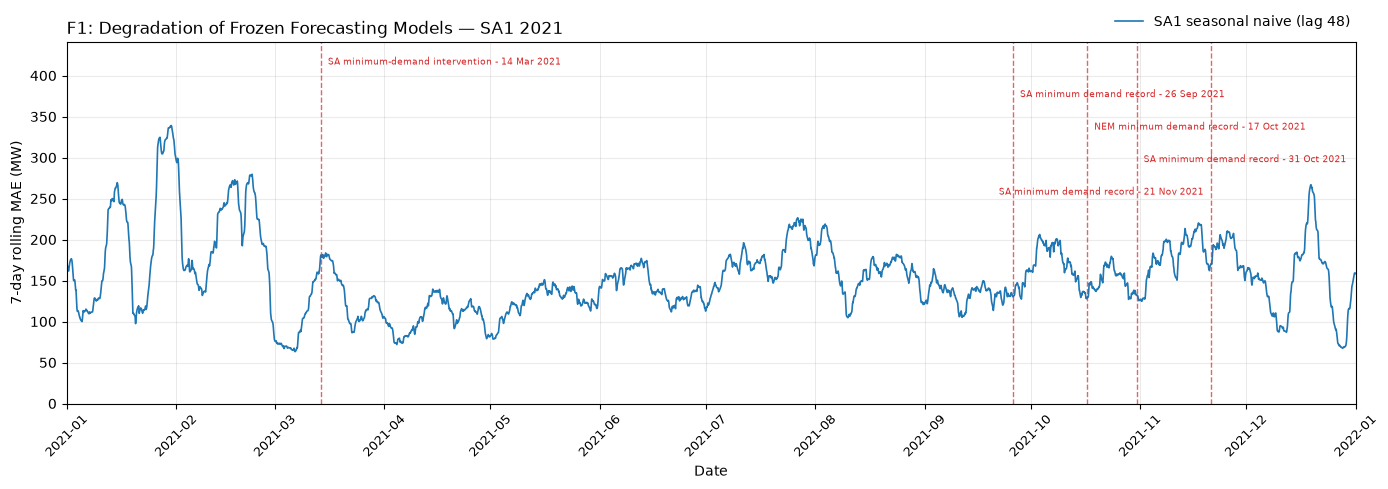

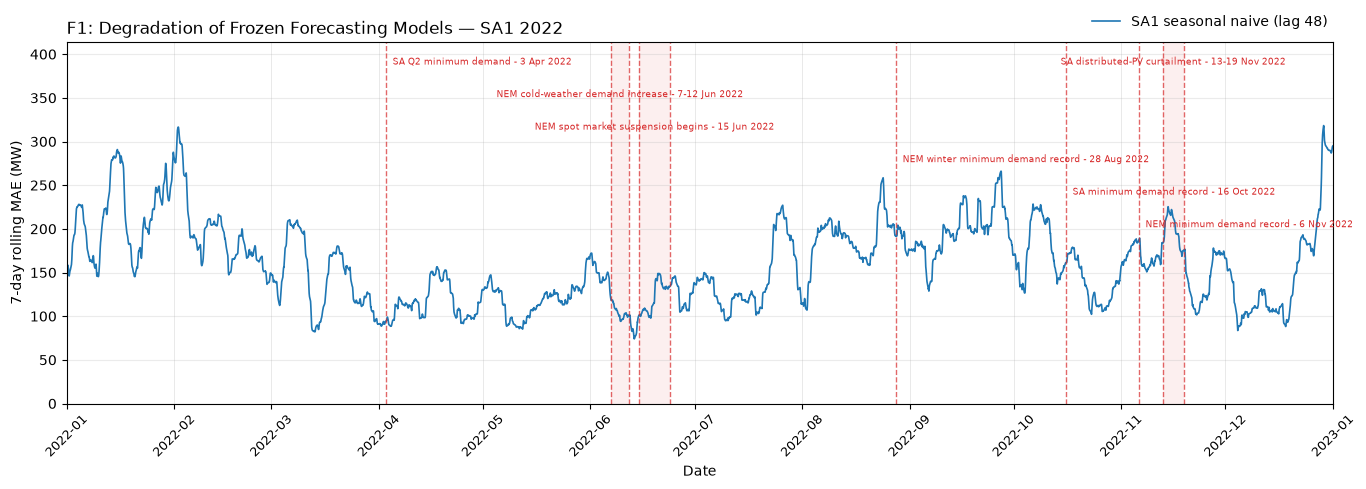

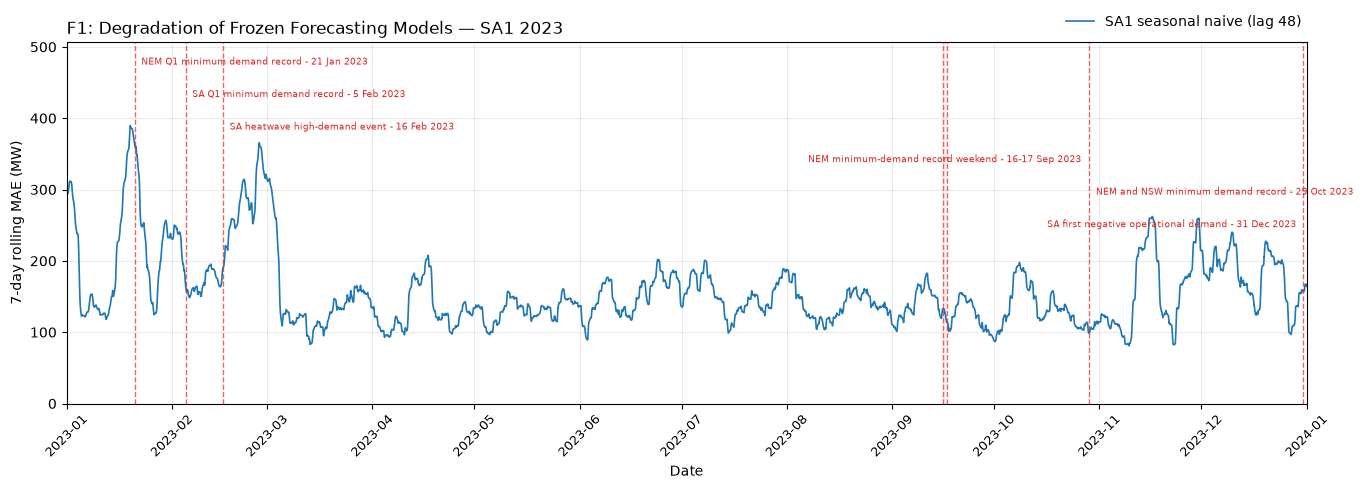

In [9]:
region_colors = {"SA1": "tab:blue", "NSW1": "tab:orange"}


def plot_region_by_year(region: str, results: pd.DataFrame, color: str) -> None:
    for year in test_years:
        year_df = results[results[TIMESTAMP_COLUMN].dt.year == year]

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(
            year_df[TIMESTAMP_COLUMN],
            year_df["ROLLING_MAE_7D"],
            label=f"{region} seasonal naive (lag 48)",
            linewidth=1.2,
            color=color,
        )

        # Headroom above the line so the vertical event labels stay readable.
        year_max = year_df["ROLLING_MAE_7D"].max()
        if pd.notna(year_max):
            ax.set_ylim(0, year_max * 1.30)

        annotate_events(ax, region, year)

        # Title on the left, legend on the same row but outside the axes on the right.
        ax.set_title(
            f"F1: Degradation of Frozen Forecasting Models — {region} {year}", loc="left"
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("7-day rolling MAE (MW)")
        format_month_axis(ax, year)
        ax.legend(
            loc="lower right",
            bbox_to_anchor=(1.0, 1.02),
            frameon=False,
            borderaxespad=0.0,
        )

        fig.tight_layout()
        fig.savefig(
            OUTPUT_DIR / f"f1_rolling_mae_{region}_{year}.png", dpi=130, bbox_inches="tight"
        )
        plt.show()


plot_region_by_year("SA1", seasonal_results["SA1"], color=region_colors["SA1"])


**SA1:** Mar–Oct 2020 (the 2020 panel, starting 7 Mar once the rolling window fills) is the calmest stretch of the whole series, averaging ~120–160 MW rolling MAE. Degradation first becomes visible spanning the **2020 and 2021 panels (Nov 2020 – Feb 2021)**, where the monthly-average rolling MAE rises to ~190–205 MW (max 339 MW in Jan 2021) — roughly 30–70% above the initial baseline. This summer-degradation pattern then repeats every year (visible as the recurring Nov–Feb peak at the edges of each panel), with the single worst episode occurring in the **2023 panel (Jan–Feb 2023)**, where rolling MAE reaches its dataset maximum of 389.7 MW on 2023-01-19. Winters (roughly Apr–Jun, mid-panel each year) consistently pull error back down to the ~110–150 MW range, so SA1's degradation looks seasonal and recurring rather than a one-time permanent shift.

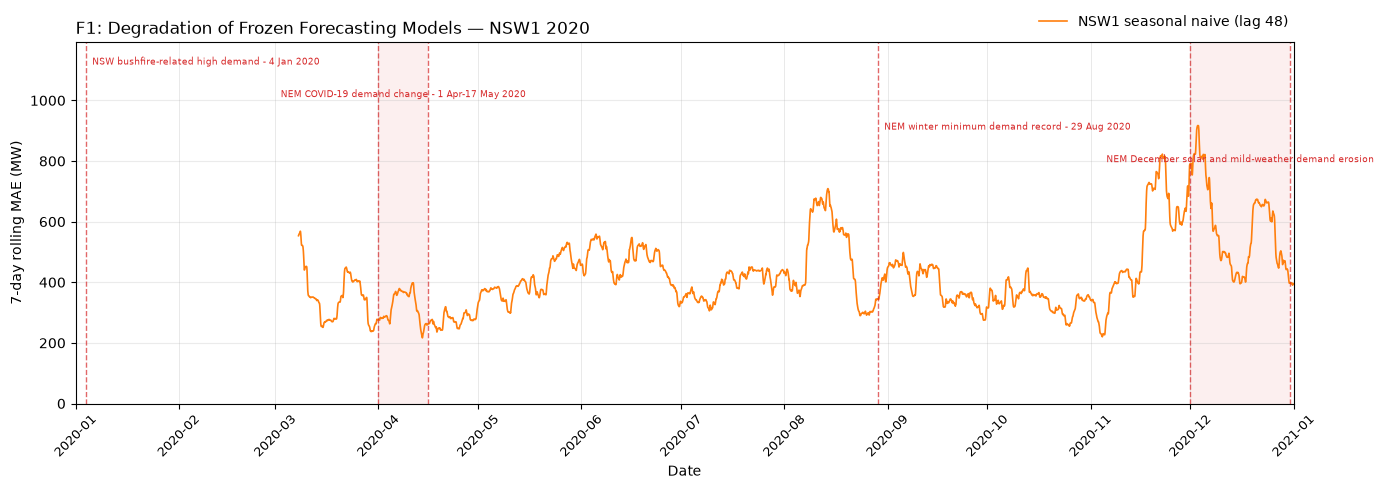

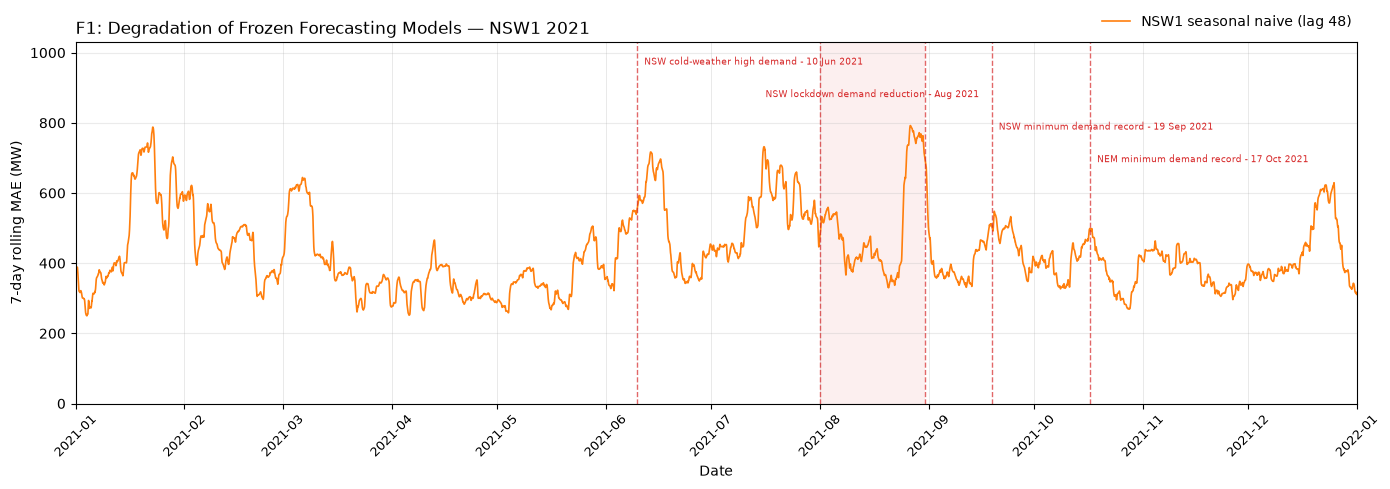

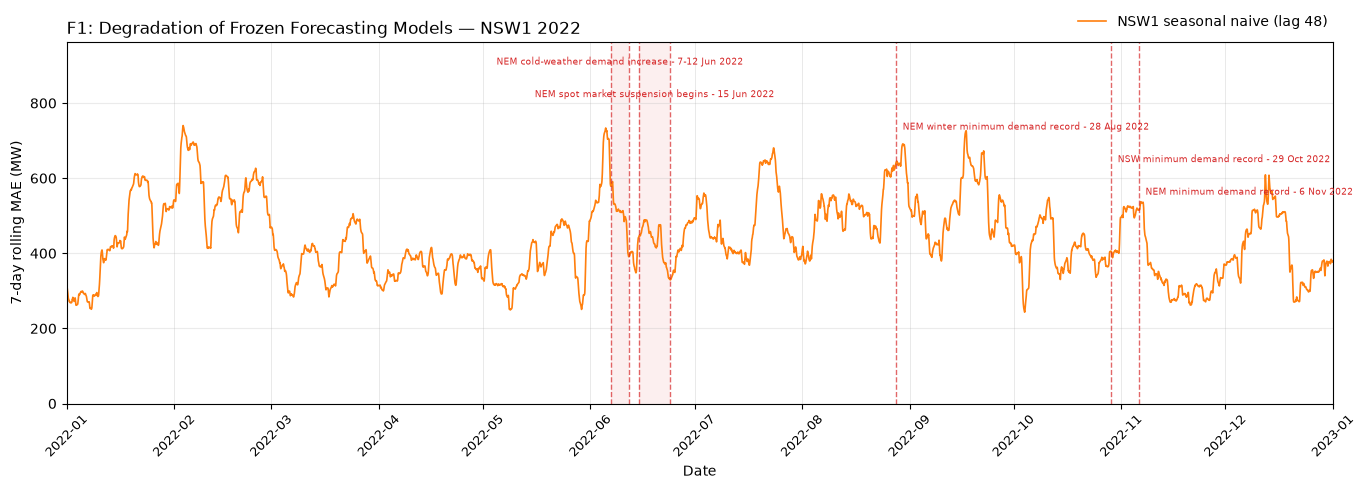

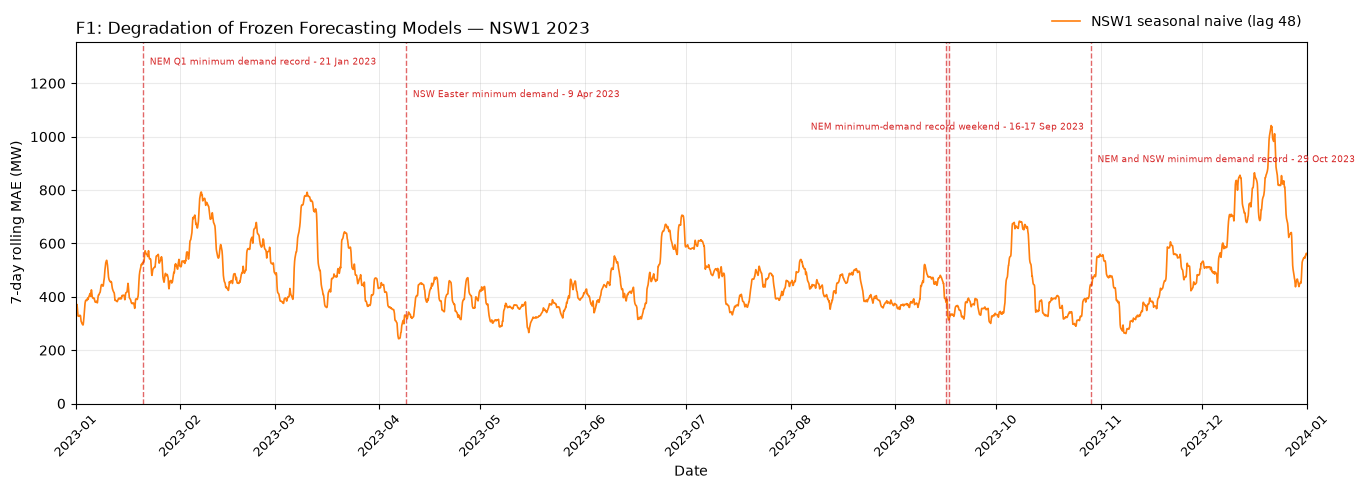

In [10]:
plot_region_by_year("NSW1", seasonal_results["NSW1"], color=region_colors["NSW1"])

**NSW1:** the baseline level is noisier than SA1's and less confined to summer — winter months (e.g. Jun–Aug 2021 and Jun–Sep 2022, mid-panel each year) also sit at 470–530 MW, comparable to summer levels, so NSW1's frozen forecast is less cleanly seasonal than SA1's. The first clear degradation episode is still the **2020 panel's Nov–Dec**, where rolling MAE jumps from a ~300–470 MW baseline to a monthly average of 515–576 MW (max 917 MW on 2020-12). The standout feature is the **right edge of the 2023 panel (Dec 2023)**: rolling MAE climbs to its dataset maximum of 1,041.6 MW on 2023-12-21 — noticeably higher than any earlier summer peak — and is still elevated (559.5 MW) at the very last test timestamp, 2024-01-01 (not drawn as its own panel — see the note above), i.e. this episode had not recovered before the test data run out, unlike every earlier summer spike.

**Suggested caption:** Seven-day rolling mean absolute error (336 half-hourly forecasts) of the frozen seasonal-naive baseline over the test stream — SA1 and NSW1 on one axis for the full test period, then one panel per region per calendar year (section 4a). The seasonal-naive baseline predicts each value using observed demand 48 intervals earlier. Documented events provide contextual reference points and are not treated as ground-truth changepoints.